# LumenY 9 — Meta Model: When Is the Base Model's Signal Profitable?

**Idea**: The base model (AUC=0.80) predicts whether price will reach MA200 within 72H. But raw probabilities don't translate to positive EV because:
- High-proba signals often fire when price is already close to MA200 (small move)
- Model fires on fresh breakdowns below MA50 (bad entries)
- Timeout exits at T+72 bleed losses

**Meta model**: Train a second classifier that sees:
- Base model probability
- Distance to MA200 in pips
- How long price has been below MA50 (bars_below_ma50)
- Hour of day
- All features_10 columns

**Target**: actual PnL > 0 (TP=MA200 at entry, timeout=T+72 close, spread=1.5p)

In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import joblib
import warnings
import gc
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import roc_auc_score, log_loss

FEATURES_10_DIR = Path('../backend/data/features_10')
PROCESSED_DIR   = Path('../backend/data/processed')
MODELS_DIR      = Path('../backend/models_10/ma_cross')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END    = '2024-06-30'
MAX_BARS     = 72
SPREAD_PIPS  = 1.5
PIP_SIZE = {
    'EURUSD':0.0001,'GBPUSD':0.0001,'USDCHF':0.0001,'AUDUSD':0.0001,
    'USDCAD':0.0001,'NZDUSD':0.0001,'EURGBP':0.0001,'EURAUD':0.0001,'AUDNZD':0.0001,
    'USDJPY':0.01,'EURJPY':0.01,'GBPJPY':0.01,'AUDJPY':0.01,'CADJPY':0.01,'CHFJPY':0.01,
}

PAIRS = [
    'EURUSD', 'GBPUSD', 'USDJPY', 'USDCHF', 'AUDUSD', 'USDCAD', 'NZDUSD',
    'EURJPY', 'GBPJPY', 'EURGBP', 'EURAUD', 'AUDJPY', 'CADJPY', 'CHFJPY', 'AUDNZD',
]

print('Ready.')


Ready.


## 1. Load Base Model, Compute Probabilities on All Signals

In [8]:
bundle = joblib.load(MODELS_DIR / 'model_long.joblib')
base_model    = bundle['model']
feature_cols  = bundle['feature_cols']
print(f'Base model loaded. Feature cols: {len(feature_cols)}')
print(f'Train end: {bundle["train_end"]}  Max bars: {bundle["max_bars"]}')

# Load all features_10 and compute base model proba
parts = []
for pair in PAIRS:
    f = pd.read_parquet(FEATURES_10_DIR / f'{pair}_features.parquet')
    f.index = pd.to_datetime(f.index)
    parts.append(f)

df_all = pd.concat(parts).sort_index()
print(f'All features: {df_all.shape}')

# Only look at bars where price is below both MAs (both_below=1)
df_sig = df_all[df_all['both_below'] == 1].copy()
print(f'Both_below signals: {len(df_sig):,}')

# Compute base model proba
X = df_sig[feature_cols].ffill().fillna(0)
df_sig['base_proba'] = base_model.predict_proba(X)[:, 1]
print(f'Base proba computed. Mean={df_sig["base_proba"].mean():.3f}')
print(f'Distribution:')
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    n = (df_sig['base_proba'] >= t).sum()
    print(f'  >= {t:.1f}: {n:,} ({n/len(df_sig):.1%})')

del df_all, X; gc.collect()


Base model loaded. Feature cols: 83
Train end: 2024-06-30  Max bars: 72
All features: (1474755, 86)
Both_below signals: 527,048
Base proba computed. Mean=0.467
Distribution:
  >= 0.3: 361,943 (68.7%)
  >= 0.4: 289,065 (54.8%)
  >= 0.5: 223,098 (42.3%)
  >= 0.6: 166,969 (31.7%)
  >= 0.7: 117,760 (22.3%)
  >= 0.8: 71,443 (13.6%)
  >= 0.9: 26,738 (5.1%)


1651

## 2. Walk Forward: Compute Actual PnL per Signal

For each signal: TP = MA200 at entry (use high prices), timeout = close at T+72.
PnL = (TP - entry)/pip - spread if TP hit, else (close[T+72] - entry)/pip - spread.

In [9]:
print('Computing actual PnL for each signal...')
print('(TP=MA200 at entry using highs, timeout=close[T+72], spread=1.5p)')

ohlc_cache = {}
for pair in PAIRS:
    ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close','high','low']]
    ohlc.index = pd.to_datetime(ohlc.index)
    ohlc_cache[pair] = ohlc

pnl_list = []
for pair in PAIRS:
    pip  = PIP_SIZE[pair]
    ohlc = ohlc_cache[pair]
    mask = df_sig['pair'] == pair

    # Compute MA200 for entry price reference
    c    = ohlc['close']
    ma50  = c.rolling(50).mean()
    ma200 = c.rolling(200).mean()

    for ts, row in df_sig[mask].iterrows():
        if ts not in ohlc.index:
            continue
        iloc   = ohlc.index.get_loc(ts)
        entry  = ohlc['close'].iloc[iloc]

        if ts not in ma200.index or pd.isna(ma200.loc[ts]):
            continue
        target = ma200.loc[ts]

        # Walk forward MAX_BARS bars
        highs  = ohlc['high'].iloc[iloc+1 : iloc+MAX_BARS+1].values
        closes = ohlc['close'].iloc[iloc+1 : iloc+MAX_BARS+1].values

        pnl = None
        for k in range(len(highs)):
            if highs[k] >= target:
                pnl = (target - entry) / pip - SPREAD_PIPS
                break

        if pnl is None:
            # Timeout exit at T+72 close
            if len(closes) > 0:
                pnl = (closes[-1] - entry) / pip - SPREAD_PIPS
            else:
                pnl = -SPREAD_PIPS

        pnl_list.append({
            'ts':           ts,
            'pair':         pair,
            'pnl':          pnl,
            'entry':        entry,
            'target':       target,
            'pips_to_ma200': (target - entry) / pip,
        })

df_pnl = pd.DataFrame(pnl_list).set_index('ts').sort_index()
print(f'Signals with PnL: {len(df_pnl):,}')
print(f'Win rate (pnl>0): {(df_pnl["pnl"] > 0).mean():.3f}')
print(f'Mean PnL: {df_pnl["pnl"].mean():.2f}p')
print(f'Mean win: {df_pnl[df_pnl["pnl"]>0]["pnl"].mean():.2f}p')
print(f'Mean loss: {df_pnl[df_pnl["pnl"]<=0]["pnl"].mean():.2f}p')


Computing actual PnL for each signal...
(TP=MA200 at entry using highs, timeout=close[T+72], spread=1.5p)
Signals with PnL: 527,048
Win rate (pnl>0): 0.616
Mean PnL: 0.37p
Mean win: 55.73p
Mean loss: -88.59p


## 3. Build Meta Dataset

Join base proba + features_10 + actual PnL. Target = pnl > 0.

In [10]:
# Join: bring in base_proba and all features_10 cols not already in df_pnl
cols_to_join = [c for c in df_sig.columns if c not in df_pnl.columns]
df_meta = df_pnl.join(df_sig[cols_to_join], how='inner')

# Add hour
df_meta['hour'] = df_meta.index.hour

# Deduplicate columns (safety)
df_meta = df_meta.loc[:, ~df_meta.columns.duplicated()]

print(f'Meta dataset: {df_meta.shape}')
print(f'Target (pnl>0): {(df_meta["pnl"] > 0).mean():.3f}')

# Split train/test
df_meta_train = df_meta[df_meta.index <= TRAIN_END].copy()
df_meta_test  = df_meta[df_meta.index >  TRAIN_END].copy()
print(f'Train: {len(df_meta_train):,}  Test: {len(df_meta_test):,}')
print(f'Train positive rate: {(df_meta_train["pnl"] > 0).mean():.3f}')
print(f'Test  positive rate: {(df_meta_test["pnl"] > 0).mean():.3f}')

# Meta feature cols
exclude = {'pnl', 'entry', 'target', 'pair', 'label_long', 'label_short',
           'both_below', 'both_above'}
meta_feature_cols = [c for c in df_meta.columns if c not in exclude]
print(f'Meta features: {len(meta_feature_cols)}')
print('  Includes: base_proba, pips_to_ma200, bars_below_ma50, hour, all features_10...')


Meta dataset: (3532300, 92)
Target (pnl>0): 0.615
Train: 3,237,491  Test: 294,809
Train positive rate: 0.613
Test  positive rate: 0.634
Meta features: 86
  Includes: base_proba, pips_to_ma200, bars_below_ma50, hour, all features_10...


## 4. Train Meta Model

In [12]:
params = {
    'objective':         'binary',
    'metric':            'auc',
    'boosting_type':     'gbdt',
    'n_estimators':      2000,
    'learning_rate':     0.02,
    'num_leaves':        32,
    'max_depth':         5,
    'min_child_samples': 100,
    'min_data_in_leaf':  100,
    'feature_fraction':  0.7,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'reg_alpha':         0.1,
    'reg_lambda':        0.2,
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,
    'device':            'gpu',
}

# Only train meta model on rows where base model actually fires (proba >= 0.4)
# Otherwise we're teaching it about all bars, not about signal quality
META_BASE_FLOOR = 0.4
df_meta_train_sig = df_meta_train[df_meta_train['base_proba'] >= META_BASE_FLOOR].copy()
df_meta_test_sig  = df_meta_test[df_meta_test['base_proba']  >= META_BASE_FLOOR].copy()
print(f'Train signals (base>={META_BASE_FLOOR}): {len(df_meta_train_sig):,}  pos_rate={(df_meta_train_sig["pnl"]>0).mean():.3f}')
print(f'Test  signals (base>={META_BASE_FLOOR}): {len(df_meta_test_sig):,}   pos_rate={(df_meta_test_sig["pnl"]>0).mean():.3f}')

X_tr = df_meta_train_sig[meta_feature_cols].ffill().fillna(0)
y_tr = (df_meta_train_sig['pnl'] > 0).astype(int)

X_te = df_meta_test_sig[meta_feature_cols].ffill().fillna(0)
y_te = (df_meta_test_sig['pnl'] > 0).astype(int)

# Walk-forward CV on train set
n = len(X_tr)
n_splits = 5
test_size = int(n * 0.1)
cv_aucs, best_iters = [], []

for fold in range(n_splits):
    test_start = int(n * 0.5) + fold * (int(n * 0.5) // n_splits)
    test_end   = test_start + test_size
    if test_end > n:
        break
    tr_idx  = list(range(0, test_start))
    val_idx = list(range(test_start, test_end))

    m = lgb.LGBMClassifier(**params)
    m.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx],
          eval_set=[(X_tr.iloc[val_idx], y_tr.iloc[val_idx])],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

    preds = m.predict_proba(X_tr.iloc[val_idx])[:, 1]
    auc   = roc_auc_score(y_tr.iloc[val_idx], preds)
    cv_aucs.append(auc)
    best_iters.append(m.best_iteration_)
    print(f'  Fold {fold+1}: AUC={auc:.4f}  iters={m.best_iteration_}')
    del m; gc.collect()

print(f'\nCV AUC: {np.mean(cv_aucs):.4f} +/- {np.std(cv_aucs):.4f}')

# Train final meta model
avg_iter = max(100, int(np.mean(best_iters)))
meta_model = lgb.LGBMClassifier(**{**params, 'n_estimators': avg_iter})
meta_model.fit(X_tr, y_tr)

joblib.dump({
    'model':             meta_model,
    'meta_feature_cols': meta_feature_cols,
    'base_floor':        META_BASE_FLOOR,
    'train_end':         TRAIN_END,
    'max_bars':          MAX_BARS,
    'spread_pips':       SPREAD_PIPS,
    'n_iters':           avg_iter,
    'cv_auc':            np.mean(cv_aucs),
}, MODELS_DIR / 'model_long_meta.joblib')
print(f'Meta model saved -> {MODELS_DIR}/model_long_meta.joblib')


Train signals (base>=0.4): 1,664,563  pos_rate=0.634
Test  signals (base>=0.4): 183,116   pos_rate=0.659
  Fold 1: AUC=0.6650  iters=8
  Fold 2: AUC=0.6173  iters=424
  Fold 3: AUC=0.6732  iters=5
  Fold 4: AUC=0.6718  iters=5
  Fold 5: AUC=0.6328  iters=6

CV AUC: 0.6520 +/- 0.0227
Meta model saved -> ..\backend\models_10\ma_cross/model_long_meta.joblib


## 5. Test Set Evaluation

In [14]:
meta_proba = meta_model.predict_proba(X_te)[:, 1]
auc = roc_auc_score(y_te, meta_proba)
print(f'Meta model test AUC: {auc:.4f}')
print(f'Positive rate: {y_te.mean():.3f}')
print(f'Test rows: {len(y_te):,}')

results = df_meta_test_sig.copy()
results['meta_proba'] = meta_proba

print(f'\nPrecision / EV at meta model thresholds:')
print(f'{"Thresh":>8} {"N":>7} {"WR":>7} {"Mean PnL":>10} {"Mean win":>10} {"Mean loss":>10}')
print('-' * 60)
for t in [0.4, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]:
    mask = results['meta_proba'] >= t
    if mask.sum() < 20: continue
    s   = results[mask]
    wr  = (s['pnl'] > 0).mean()
    ev  = s['pnl'].mean()
    mw  = s[s['pnl']>0]['pnl'].mean() if (s['pnl']>0).any() else 0
    ml  = s[s['pnl']<=0]['pnl'].mean() if (s['pnl']<=0).any() else 0
    print(f'{t:>8.2f} {mask.sum():>7,} {wr:>7.1%} {ev:>10.2f} {mw:>10.1f} {ml:>10.1f}')


Meta model test AUC: 0.6437
Positive rate: 0.659
Test rows: 183,116

Precision / EV at meta model thresholds:
  Thresh       N      WR   Mean PnL   Mean win  Mean loss
------------------------------------------------------------
    0.40 180,632   66.8%       0.40       50.0      -99.5
    0.50 180,629   66.8%       0.39       50.0      -99.5
    0.55 161,479   68.1%       0.30       44.8      -94.6
    0.60 116,248   71.3%      -1.71       33.0      -87.8
    0.65  84,048   76.1%       0.42       25.6      -79.5
    0.70  58,777   81.1%       1.46       18.3      -71.0
    0.75  38,439   86.4%      -0.54       10.8      -72.5
    0.80  25,126   90.5%      -0.17        7.2      -70.9


## 6. Combined Filter: base_proba >= X AND meta_proba >= Y

In [15]:
print('Combined base + meta filter:')
print(f'{"Base":>6} {"Meta":>6} {"N":>7} {"WR":>7} {"EV":>8} {"Mean win":>10} {"Mean loss":>10}')
print('-' * 65)
for bt in [0.5, 0.6]:
    for mt in [0.5, 0.55, 0.6, 0.65, 0.7]:
        mask = (results['base_proba'] >= bt) & (results['meta_proba'] >= mt)
        if mask.sum() < 15: continue
        s  = results[mask]
        wr = (s['pnl'] > 0).mean()
        ev = s['pnl'].mean()
        mw = s[s['pnl']>0]['pnl'].mean() if (s['pnl']>0).any() else 0
        ml = s[s['pnl']<=0]['pnl'].mean() if (s['pnl']<=0).any() else 0
        print(f'{bt:>6.1f} {mt:>6.2f} {mask.sum():>7,} {wr:>7.1%} {ev:>8.2f} {mw:>10.1f} {ml:>10.1f}')


Combined base + meta filter:
  Base   Meta       N      WR       EV   Mean win  Mean loss
-----------------------------------------------------------------
   0.5   0.50 144,002   68.1%     1.45       47.6      -97.0
   0.5   0.55 131,426   69.3%     1.64       43.0      -91.7
   0.5   0.60  98,730   72.0%    -0.74       32.2      -85.4
   0.5   0.65  72,813   76.4%     0.90       25.0      -76.9
   0.5   0.70  51,400   81.2%     1.03       17.8      -71.1
   0.6   0.50 110,342   69.5%     3.02       45.6      -93.9
   0.6   0.55 102,441   70.5%     3.34       41.6      -88.2
   0.6   0.60  78,094   73.1%    -0.16       30.7      -84.1
   0.6   0.65  60,443   76.8%     1.28       24.1      -74.5
   0.6   0.70  43,472   81.2%     0.43       17.0      -71.0


## 7. Feature Importance of Meta Model

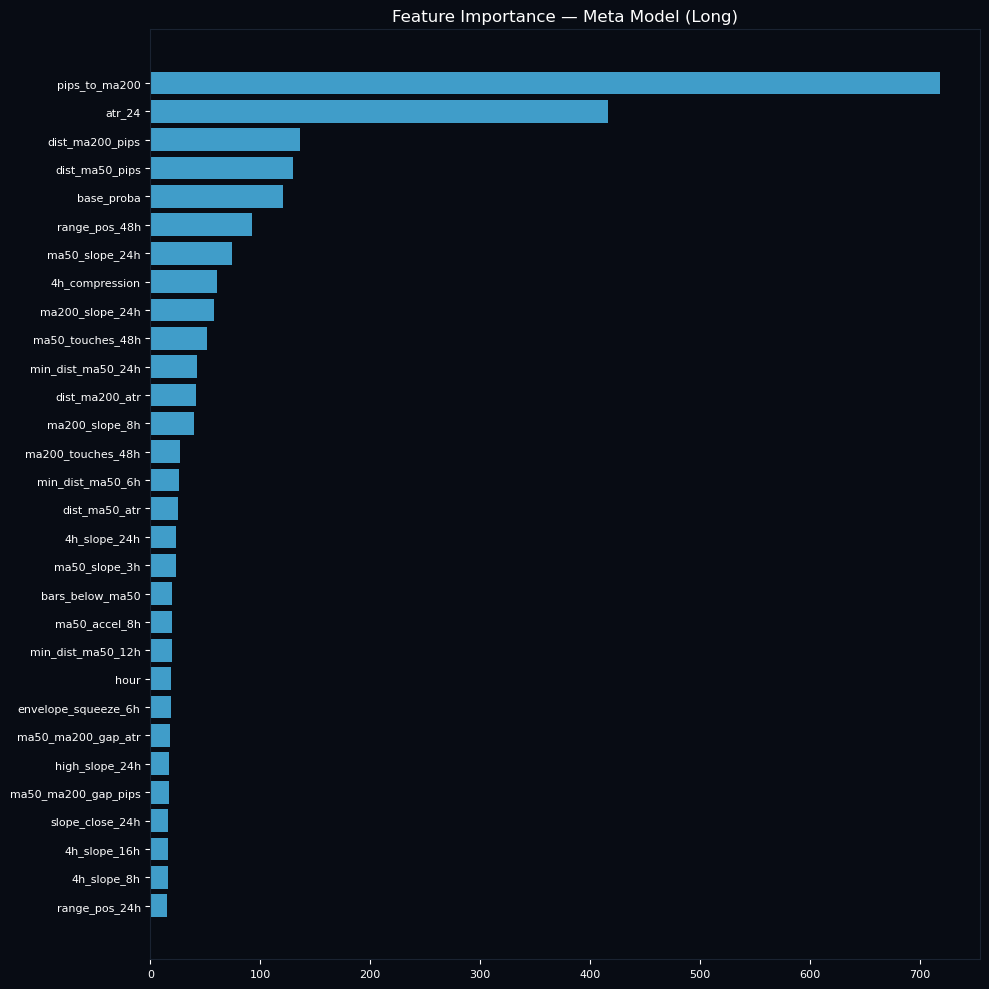

In [16]:
import matplotlib.pyplot as plt

importance = pd.Series(meta_model.feature_importances_, index=meta_feature_cols)
importance = importance.sort_values(ascending=True).tail(30)

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor('#080c14')
ax.set_facecolor('#080c14')
ax.barh(importance.index, importance.values, color='#4fc3f7', alpha=0.8)
ax.tick_params(colors='white', labelsize=8)
ax.set_title('Feature Importance — Meta Model (Long)', color='white', fontsize=12)
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
plt.tight_layout()
plt.show()


## 8. Per-Pair EV at Best Meta Threshold

In [17]:
best_bt, best_mt = 0.5, 0.6
mask = (results['base_proba'] >= best_bt) & (results['meta_proba'] >= best_mt)
print(f'Using base>={best_bt}, meta>={best_mt}: N={mask.sum():,}, WR={(results[mask]["pnl"]>0).mean():.1%}, EV={results[mask]["pnl"].mean():.2f}p')

print(f'\nPer-pair breakdown:')
print(f'{"Pair":>10} {"N":>6} {"WR":>7} {"EV":>8} {"Mean win":>10} {"Mean loss":>10}')
print('-'*55)
for pair, g in results[mask].groupby('pair'):
    if len(g) < 5: continue
    wr = (g['pnl'] > 0).mean()
    ev = g['pnl'].mean()
    mw = g[g['pnl']>0]['pnl'].mean() if (g['pnl']>0).any() else 0
    ml = g[g['pnl']<=0]['pnl'].mean() if (g['pnl']<=0).any() else 0
    print(f'{pair:>10} {len(g):>6} {wr:>7.1%} {ev:>8.2f} {mw:>10.1f} {ml:>10.1f}')


Using base>=0.5, meta>=0.6: N=98,730, WR=72.0%, EV=-0.74p

Per-pair breakdown:
      Pair      N      WR       EV   Mean win  Mean loss
-------------------------------------------------------
    AUDJPY   6505   80.3%     0.29       35.3     -142.3
    AUDNZD   7715   75.9%     6.94       21.4      -38.5
    AUDUSD   8503   67.7%    -0.52       24.2      -52.3
    CADJPY   6531   70.8%    -6.43       37.0     -111.9
    CHFJPY   5432   76.2%    -0.93       45.7     -150.1
    EURAUD   3991   69.5%    -5.85       36.2     -101.9
    EURGBP  10444   62.8%     0.02       19.0      -32.0
    EURJPY   6081   76.2%    -6.70       40.9     -159.2
    EURUSD   6108   69.0%    -2.52       28.9      -72.6
    GBPJPY   5341   81.4%    -4.59       48.1     -235.1
    GBPUSD   5145   74.7%     2.10       37.6     -102.8
    NZDUSD   8647   65.8%    -0.45       27.1      -53.3
    USDCAD   5663   71.6%     4.85       32.2      -64.1
    USDCHF   7136   70.3%    -2.18       25.1      -66.8
    USDJPY

## 9. Distribution Over Time (signal frequency)

In [18]:
sub = results[(results['base_proba'] >= best_bt) & (results['meta_proba'] >= best_mt)].copy()

sub['month'] = sub.index.to_period('M')
monthly = sub.groupby('month').agg(n=('pnl','count'), wr=('pnl', lambda x: (x>0).mean()), ev=('pnl','mean'))
print(f'Monthly signal distribution (base>={best_bt}, meta>={best_mt}):')
print(f'{"Month":>10} {"N":>5} {"WR":>7} {"EV":>8}')
print('-'*35)
for month, row in monthly.iterrows():
    bar = '#' * int(row['n'] / monthly['n'].max() * 20)
    print(f'{str(month):>10} {int(row["n"]):>5} {row["wr"]:>7.1%} {row["ev"]:>8.2f}  {bar}')

print(f'\nAverage signals/month: {monthly["n"].mean():.1f}')
print(f'Overall WR: {(sub["pnl"]>0).mean():.1%}')
print(f'Overall EV: {sub["pnl"].mean():.2f}p')


Monthly signal distribution (base>=0.5, meta>=0.6):
     Month     N      WR       EV
-----------------------------------
   2024-07  4401   43.7%   -69.95  #########
   2024-08  3625   58.5%     1.27  #######
   2024-09  6150   58.8%   -30.57  #############
   2024-10  5590   67.8%     2.47  ############
   2024-11  9280   67.9%   -13.11  ####################
   2024-12  5557   76.1%    24.25  ###########
   2025-01  8857   71.6%     0.72  ###################
   2025-02  3552   66.7%    -5.42  #######
   2025-03  6811   73.1%    12.59  ##############
   2025-04  4679   80.2%     6.63  ##########
   2025-05  7159   79.1%     8.41  ###############
   2025-06  4321   88.4%    15.07  #########
   2025-07  5813   74.7%     4.93  ############
   2025-08  7270   88.0%    15.27  ###############
   2025-09  3298   65.9%   -15.42  #######
   2025-10  5020   77.8%     5.49  ##########
   2025-11  3366   72.6%     6.23  #######
   2025-12  3981   72.5%     6.08  ########

Average signals/month: 5

## 10. SL Simulation on Meta-Filtered Signals

In [19]:
print('SL simulation on meta-filtered signals (TP=MA200, timeout=T+72)')
print(f'Filter: base>={best_bt}, meta>={best_mt}')
print()

sim_data = []
for pair in PAIRS:
    pip  = PIP_SIZE[pair]
    ohlc = ohlc_cache[pair]
    filt = results[(results['pair'] == pair) &
                   (results['base_proba'] >= best_bt) &
                   (results['meta_proba'] >= best_mt)]
    for ts, row in filt.iterrows():
        if ts not in ohlc.index: continue
        iloc = ohlc.index.get_loc(ts)
        sim_data.append({
            'pair':   pair,
            'entry':  row['entry'],
            'target': row['target'],
            'pip':    pip,
            'lows':   ohlc['low'].iloc[iloc+1:iloc+MAX_BARS+1].values,
            'highs':  ohlc['high'].iloc[iloc+1:iloc+MAX_BARS+1].values,
            'closes': ohlc['close'].iloc[iloc+1:iloc+MAX_BARS+1].values,
            'pips_to_ma200': row['pips_to_ma200'],
        })

print(f'Signals to simulate: {len(sim_data):,}')
print(f'{"SL":>8} {"N TP":>8} {"N SL":>8} {"N TO":>8} {"WR":>7} {"Avg win":>9} {"Avg loss":>9} {"EV":>8} {"Sharpe":>8}')
print('-'*80)
for sl_pips in [30, 40, 50, 60, 75, 100, 150, 999]:
    pnls = []
    for s in sim_data:
        pip    = s['pip']
        entry  = s['entry']
        target = s['target']
        sl_lvl = entry - sl_pips * pip
        pnl = None
        for k in range(len(s['lows'])):
            if s['lows'][k] <= sl_lvl:
                pnl = -sl_pips - SPREAD_PIPS; break
            if s['highs'][k] >= target:
                pnl = (target - entry) / pip - SPREAD_PIPS; break
        if pnl is None:
            pnl = (s['closes'][-1] - entry) / pip - SPREAD_PIPS if len(s['closes']) > 0 else -SPREAD_PIPS
        pnls.append(pnl)
    pnls   = np.array(pnls)
    wins   = pnls[pnls > 0]
    losses = pnls[pnls <= 0]
    n_sl   = (pnls <= -(sl_pips - 0.1)).sum() if sl_pips < 999 else 0
    n_tp   = (pnls > 0).sum()
    n_to   = len(pnls) - n_sl - n_tp
    ev     = pnls.mean()
    sharpe = ev / pnls.std() * np.sqrt(252) if pnls.std() > 0 else 0
    lbl    = f'{sl_pips}p' if sl_pips < 999 else 'none'
    print(f'{lbl:>8} {n_tp:>8,} {n_sl:>8,} {n_to:>8,} {(pnls>0).mean():>7.1%} '
          f'{wins.mean() if len(wins) else 0:>9.1f} '
          f'{losses.mean() if len(losses) else 0:>9.1f} '
          f'{ev:>8.2f} {sharpe:>8.3f}')


SL simulation on meta-filtered signals (TP=MA200, timeout=T+72)
Filter: base>=0.5, meta>=0.6

Signals to simulate: 98,730
      SL     N TP     N SL     N TO      WR   Avg win  Avg loss       EV   Sharpe
--------------------------------------------------------------------------------
     30p   41,693   56,440      597   42.2%      28.0     -31.3    -6.24   -2.219
     40p   47,631   49,609    1,490   48.2%      28.7     -40.6    -7.20   -2.328
     50p   52,281   43,823    2,626   53.0%      29.2     -49.5    -7.82   -2.338
     60p   56,148   38,464    4,118   56.9%      29.6     -57.4    -7.90   -2.213
     75p   60,248   32,279    6,203   61.0%      29.9     -67.9    -8.25   -2.129
    100p   63,224   25,681    9,825   64.0%      30.5     -82.2   -10.05   -2.322
    150p   66,348   16,987   15,395   67.2%      31.2    -100.8   -12.10   -2.402
    none   70,569        0   28,161   71.5%      32.1    -108.2    -7.90   -1.063


In [20]:
print('Distance floor + meta filter analysis')
print(f'{"MinDist":>8} {"Base":>5} {"Meta":>5} {"N":>7} {"WR":>7} {"EV":>8} {"Avg win":>9} {"Avg loss":>9}')
print('-' * 68)
for min_dist in [20, 30, 40, 50, 75]:
    for bt in [0.5, 0.6]:
        for mt in [0.55, 0.65, 0.70]:
            mask = (
                (results['base_proba'] >= bt) &
                (results['meta_proba'] >= mt) &
                (results['pips_to_ma200'] >= min_dist)
            )
            if mask.sum() < 30: continue
            s  = results[mask]
            wr = (s['pnl'] > 0).mean()
            ev = s['pnl'].mean()
            mw = s[s['pnl']>0]['pnl'].mean() if (s['pnl']>0).any() else 0
            ml = s[s['pnl']<=0]['pnl'].mean() if (s['pnl']<=0).any() else 0
            print(f'{min_dist:>8} {bt:>5.1f} {mt:>5.2f} {mask.sum():>7,} {wr:>7.1%} {ev:>8.2f} {mw:>9.1f} {ml:>9.1f}')
    print()


Distance floor + meta filter analysis
 MinDist  Base  Meta       N      WR       EV   Avg win  Avg loss
--------------------------------------------------------------------
      20   0.5  0.55 103,486   64.2%     2.16      55.7     -93.7
      20   0.5  0.65  44,873   69.1%     1.64      37.7     -78.9
      20   0.5  0.70  23,462   72.9%     2.58      30.4     -72.4
      20   0.6  0.55  78,771   65.3%     4.43      54.9     -90.3
      20   0.6  0.65  36,773   69.6%     2.31      36.5     -76.0
      20   0.6  0.70  19,803   73.0%     1.33      28.6     -72.3

      30   0.5  0.55  87,417   62.4%     2.85      62.8     -96.8
      30   0.5  0.65  28,842   66.6%     3.45      46.8     -82.9
      30   0.5  0.70   8,520   70.7%     9.87      44.8     -74.3
      30   0.6  0.55  65,402   63.6%     5.75      62.4     -93.2
      30   0.6  0.65  23,412   67.4%     4.76      45.0     -78.6
      30   0.6  0.70   7,264   71.3%     6.88      39.3     -73.7

      40   0.5  0.55  72,253   61

In [21]:
# SL sim on the promising subset: base>=0.6, meta>=0.70, pips_to_ma200>=30
import numpy as np

sub_mask = (
    (results['base_proba'] >= 0.6) &
    (results['meta_proba'] >= 0.70) &
    (results['pips_to_ma200'] >= 30)
)
sub = results[sub_mask]
print(f'Subset: {len(sub):,} signals, WR={( sub["pnl"]>0).mean():.1%}, EV={sub["pnl"].mean():.2f}p')

sim_sub = []
for pair in PAIRS:
    pip  = PIP_SIZE[pair]
    ohlc = ohlc_cache[pair]
    filt = sub[sub['pair'] == pair]
    for ts, row in filt.iterrows():
        if ts not in ohlc.index: continue
        iloc = ohlc.index.get_loc(ts)
        sim_sub.append({
            'pip':    pip,
            'entry':  row['entry'],
            'target': row['target'],
            'lows':   ohlc['low'].iloc[iloc+1:iloc+MAX_BARS+1].values,
            'highs':  ohlc['high'].iloc[iloc+1:iloc+MAX_BARS+1].values,
            'closes': ohlc['close'].iloc[iloc+1:iloc+MAX_BARS+1].values,
            'pips_to_ma200': row['pips_to_ma200'],
        })

print(f'\nSL simulation (base>=0.6, meta>=0.70, pips_to_ma200>=30):')
print(f'{"SL":>8} {"N":>6} {"N TP":>7} {"N SL":>7} {"N TO":>7} {"WR":>7} {"Avg win":>9} {"Avg loss":>9} {"EV":>8} {"Sharpe":>8}')
print('-' * 80)
for sl_pips in [30, 40, 50, 60, 75, 100, 150, 999]:
    pnls = []
    for s in sim_sub:
        pip    = s['pip']
        entry  = s['entry']
        target = s['target']
        sl_lvl = entry - sl_pips * pip
        pnl = None
        for k in range(len(s['lows'])):
            if s['lows'][k] <= sl_lvl:
                pnl = -sl_pips - SPREAD_PIPS; break
            if s['highs'][k] >= target:
                pnl = (target - entry) / pip - SPREAD_PIPS; break
        if pnl is None:
            pnl = (s['closes'][-1] - entry) / pip - SPREAD_PIPS if len(s['closes']) > 0 else -SPREAD_PIPS
        pnls.append(pnl)
    pnls   = np.array(pnls)
    wins   = pnls[pnls > 0]
    losses = pnls[pnls <= 0]
    n_sl   = (pnls <= -(sl_pips - 0.1)).sum() if sl_pips < 999 else 0
    n_tp   = (pnls > 0).sum()
    n_to   = len(pnls) - n_sl - n_tp
    ev     = pnls.mean()
    sharpe = ev / pnls.std() * np.sqrt(252) if pnls.std() > 0 else 0
    lbl    = f'{sl_pips}p' if sl_pips < 999 else 'none'
    print(f'{lbl:>8} {len(pnls):>6,} {n_tp:>7,} {n_sl:>7,} {n_to:>7,} {(pnls>0).mean():>7.1%} '
          f'{wins.mean() if len(wins) else 0:>9.1f} '
          f'{losses.mean() if len(losses) else 0:>9.1f} '
          f'{ev:>8.2f} {sharpe:>8.3f}')


Subset: 7,264 signals, WR=71.3%, EV=6.88p

SL simulation (base>=0.6, meta>=0.70, pips_to_ma200>=30):
      SL      N    N TP    N SL    N TO      WR   Avg win  Avg loss       EV   Sharpe
--------------------------------------------------------------------------------
     30p  7,264   2,496   4,723      45   34.4%      39.0     -31.3    -7.14   -2.124
     40p  7,264   2,974   4,174     116   40.9%      38.5     -40.7    -8.24   -2.273
     50p  7,264   3,483   3,595     186   47.9%      38.0     -49.6    -7.58   -1.968
     60p  7,264   3,870   3,016     378   53.3%      37.9     -56.5    -6.25   -1.543
     75p  7,264   4,191   2,553     520   57.7%      38.1     -67.0    -6.34   -1.450
    100p  7,264   4,442   2,063     759   61.2%      38.7     -82.0    -8.22   -1.698
    150p  7,264   4,748   1,358   1,158   65.4%      39.0    -100.9    -9.45   -1.710
    none  7,264   5,136       0   2,128   70.7%      39.4     -97.9    -0.83   -0.109


In [22]:
# How many timeout losers eventually reach TP if we wait longer?
print('Checking timeout losers: do they reach MA200 if we wait beyond 72H?')
print('(base>=0.6, meta>=0.70, pips_to_ma200>=30)')
print()

MAX_EXTENDED = 240  # look up to 240H (10 days)
recovery_bars = []

for pair in PAIRS:
    pip  = PIP_SIZE[pair]
    ohlc = ohlc_cache[pair]
    filt = sub[sub['pair'] == pair]
    for ts, row in filt.iterrows():
        if ts not in ohlc.index: continue
        iloc   = ohlc.index.get_loc(ts)
        target = row['target']
        highs  = ohlc['high'].iloc[iloc+1 : iloc+MAX_EXTENDED+1].values

        # Check if it hit TP in first 72H
        hit_72 = any(h >= target for h in highs[:MAX_BARS])
        # Check if it hits TP between 72H and 240H
        hit_extended = any(h >= target for h in highs[MAX_BARS:])
        # How many bars to first TP hit (if at all)
        hit_bar = next((k+1 for k, h in enumerate(highs) if h >= target), None)

        recovery_bars.append({
            'pair': pair,
            'hit_72': hit_72,
            'hit_extended': hit_extended,
            'hit_ever': hit_72 or hit_extended,
            'hit_bar': hit_bar,
            'pips_to_ma200': row['pips_to_ma200'],
        })

df_rec = pd.DataFrame(recovery_bars)
timeouts = df_rec[~df_rec['hit_72']]

print(f'Total signals:          {len(df_rec):,}')
print(f'Hit TP within 72H:      {df_rec["hit_72"].sum():,} ({df_rec["hit_72"].mean():.1%})')
print(f'Timeout (no hit in 72H):{len(timeouts):,} ({len(timeouts)/len(df_rec):.1%})')
print(f'Of timeouts, hit by 240H: {timeouts["hit_extended"].sum():,} ({timeouts["hit_extended"].mean():.1%})')
print(f'Of timeouts, never hit:   {(~timeouts["hit_ever"]).sum():,} ({(~timeouts["hit_ever"]).mean():.1%})')

print(f'\nHit bar distribution (all that hit TP, up to 240H):')
hits = df_rec[df_rec['hit_ever']]['hit_bar'].dropna()
for lo, hi in [(1,12),(12,24),(24,48),(48,72),(72,120),(120,180),(180,240)]:
    n = ((hits >= lo) & (hits < hi)).sum()
    print(f'  {lo:>4}-{hi:>4}H: {n:>5,} ({n/len(df_rec):.1%})')


Checking timeout losers: do they reach MA200 if we wait beyond 72H?
(base>=0.6, meta>=0.70, pips_to_ma200>=30)

Total signals:          7,264
Hit TP within 72H:      4,744 (65.3%)
Timeout (no hit in 72H):2,520 (34.7%)
Of timeouts, hit by 240H: 1,295 (51.4%)
Of timeouts, never hit:   1,225 (48.6%)

Hit bar distribution (all that hit TP, up to 240H):
     1-  12H: 2,275 (31.3%)
    12-  24H:   833 (11.5%)
    24-  48H:   966 (13.3%)
    48-  72H:   642 (8.8%)
    72- 120H:   530 (7.3%)
   120- 180H:   374 (5.1%)
   180- 240H:   415 (5.7%)


In [23]:
# Simulate: TP=MA200, no SL, timeout at T+X close, vary X
print('Timeout sensitivity — no SL, vary max hold window')
print(f'{"Window":>8} {"N TP":>7} {"N TO":>7} {"WR":>7} {"Avg win":>9} {"Avg timeout":>12} {"EV":>8}')
print('-' * 65)

for max_hold in [24, 48, 72, 120, 168, 240]:
    tp_pnls, to_pnls = [], []
    for pair in PAIRS:
        pip  = PIP_SIZE[pair]
        ohlc = ohlc_cache[pair]
        filt = sub[sub['pair'] == pair]
        for ts, row in filt.iterrows():
            if ts not in ohlc.index: continue
            iloc   = ohlc.index.get_loc(ts)
            entry  = row['entry']
            target = row['target']
            highs  = ohlc['high'].iloc[iloc+1:iloc+max_hold+1].values
            closes = ohlc['close'].iloc[iloc+1:iloc+max_hold+1].values
            hit = next((k for k, h in enumerate(highs) if h >= target), None)
            if hit is not None:
                tp_pnls.append((target - entry) / pip - SPREAD_PIPS)
            else:
                to_pnls.append((closes[-1] - entry) / pip - SPREAD_PIPS if len(closes) > 0 else -SPREAD_PIPS)

    all_pnls = np.array(tp_pnls + to_pnls)
    wr  = len(tp_pnls) / len(all_pnls)
    ev  = all_pnls.mean()
    mto = np.mean(to_pnls) if to_pnls else 0
    mtp = np.mean(tp_pnls) if tp_pnls else 0
    print(f'{max_hold:>7}H {len(tp_pnls):>7,} {len(to_pnls):>7,} {wr:>7.1%} {mtp:>9.1f} {mto:>12.1f} {ev:>8.2f}')


Timeout sensitivity — no SL, vary max hold window
  Window    N TP    N TO      WR   Avg win  Avg timeout       EV
-----------------------------------------------------------------
     24H   3,155   4,109   43.4%      39.7        -22.8     4.38
     48H   4,092   3,172   56.3%      38.8        -40.7     4.07
     72H   4,744   2,520   65.3%      38.4        -52.5     6.88
    120H   5,253   2,011   72.3%      38.9        -86.4     4.20
    168H   5,536   1,728   76.2%      40.5       -124.8     1.17
    240H   6,039   1,225   83.1%      42.5       -142.8    11.22


In [25]:
recovery_rows = []
for pair in PAIRS:
    pip  = PIP_SIZE[pair]
    ohlc = ohlc_cache[pair]
    filt = sub[sub['pair'] == pair]
    for ts, row in filt.iterrows():
        if ts not in ohlc.index: continue
        iloc   = ohlc.index.get_loc(ts)
        target = row['target']
        highs  = ohlc['high'].iloc[iloc+1:iloc+241].values
        lows   = ohlc['low'].iloc[iloc+1:iloc+241].values
        closes = ohlc['close'].iloc[iloc+1:iloc+241].values
        hit_bar = next((k+1 for k, h in enumerate(highs) if h >= target), None)
        max_dd = (ohlc['close'].iloc[iloc] - lows.min()) / pip if len(lows) > 0 else 0
        recovery_rows.append({
            'ts':              ts,
            'pair':            pair,
            'hit_ever':        hit_bar is not None,
            'hit_bar':         hit_bar,
            'pips_to_ma200':   row['pips_to_ma200'],
            'bars_below_ma50': row.get('bars_below_ma50', np.nan),
            'base_proba':      row['base_proba'],
            'meta_proba':      row['meta_proba'],
            'max_dd_pips':     max_dd,
            'hour':            ts.hour,
        })

df_r = pd.DataFrame(recovery_rows)  # integer index, no duplicates

never   = df_r[~df_r['hit_ever']]
hitters = df_r[df_r['hit_ever']]

print(f'Never hit (240H): {len(never):,}  |  Hit: {len(hitters):,}')
print()
for col in ['pips_to_ma200', 'bars_below_ma50', 'base_proba', 'meta_proba', 'max_dd_pips', 'hour']:
    nh = never[col].mean()
    h  = hitters[col].mean()
    print(f'{col:<22}  never={nh:>8.2f}   hit={h:>8.2f}   diff={nh-h:>+8.2f}')

print(f'\nPips to MA200 distribution:')
for lo, hi in [(30,40),(40,50),(50,75),(75,100),(100,150),(150,999)]:
    n_hit  = ((hitters['pips_to_ma200']>=lo)&(hitters['pips_to_ma200']<hi)).sum()
    n_miss = ((never['pips_to_ma200']>=lo)&(never['pips_to_ma200']<hi)).sum()
    tot    = n_hit + n_miss
    if tot == 0: continue
    print(f'  {lo:>4}-{hi:>4}p: hit={n_hit:>4,} miss={n_miss:>4,}  hit_rate={n_hit/tot:.1%}')


Never hit (240H): 1,225  |  Hit: 6,039

pips_to_ma200           never=   81.06   hit=   43.96   diff=  +37.10
bars_below_ma50         never=   16.20   hit=   18.33   diff=   -2.13
base_proba              never=    0.76   hit=    0.76   diff=   -0.00
meta_proba              never=    0.72   hit=    0.72   diff=   -0.00
max_dd_pips             never=  426.70   hit=  313.71   diff= +112.99
hour                    never=   11.40   hit=   11.77   diff=   -0.37

Pips to MA200 distribution:
    30-  40p: hit=4,490 miss= 764  hit_rate=85.5%
    40-  50p: hit=1,286 miss= 279  hit_rate=82.2%
    50-  75p: hit= 130 miss=  38  hit_rate=77.4%
    75- 100p: hit=  19 miss=   2  hit_rate=90.5%
   100- 150p: hit=   2 miss=   0  hit_rate=100.0%
   150- 999p: hit= 105 miss= 142  hit_rate=42.5%


In [26]:
print('Impact of capping pips_to_ma200 < 150 on the 240H window sim:')
sub_capped = sub[sub['pips_to_ma200'] < 150]
print(f'Signals after cap: {len(sub_capped):,} (removed {len(sub)-len(sub_capped):,} with dist>=150p)')
print()

for max_hold in [72, 120, 168, 240]:
    tp_pnls, to_pnls = [], []
    for pair in PAIRS:
        pip  = PIP_SIZE[pair]
        ohlc = ohlc_cache[pair]
        filt = sub_capped[sub_capped['pair'] == pair]
        for ts, row in filt.iterrows():
            if ts not in ohlc.index: continue
            iloc   = ohlc.index.get_loc(ts)
            entry  = row['entry']
            target = row['target']
            highs  = ohlc['high'].iloc[iloc+1:iloc+max_hold+1].values
            closes = ohlc['close'].iloc[iloc+1:iloc+max_hold+1].values
            hit = next((k for k, h in enumerate(highs) if h >= target), None)
            if hit is not None:
                tp_pnls.append((target - entry) / pip - SPREAD_PIPS)
            else:
                to_pnls.append((closes[-1] - entry) / pip - SPREAD_PIPS if len(closes) > 0 else -SPREAD_PIPS)

    all_pnls = np.array(tp_pnls + to_pnls)
    wr  = len(tp_pnls) / len(all_pnls)
    ev  = all_pnls.mean()
    mto = np.mean(to_pnls) if to_pnls else 0
    mtp = np.mean(tp_pnls) if tp_pnls else 0
    print(f'{max_hold:>4}H  N={len(all_pnls):>5,}  WR={wr:.1%}  avg_win={mtp:.1f}  avg_timeout={mto:.1f}  EV={ev:.2f}p')

print()
# Also check with a SL now that we've cut the worst losers
print('SL sim on capped subset (base>=0.6, meta>=0.70, 30<=pips<150), 240H window:')
print(f'{"SL":>8} {"WR":>7} {"Avg win":>9} {"Avg loss":>9} {"EV":>8} {"Sharpe":>8}')
print('-'*55)
for sl_pips in [50, 75, 100, 150, 200, 999]:
    pnls = []
    for pair in PAIRS:
        pip  = PIP_SIZE[pair]
        ohlc = ohlc_cache[pair]
        filt = sub_capped[sub_capped['pair'] == pair]
        for ts, row in filt.iterrows():
            if ts not in ohlc.index: continue
            iloc   = ohlc.index.get_loc(ts)
            entry  = row['entry']
            target = row['target']
            sl_lvl = entry - sl_pips * pip
            highs  = ohlc['high'].iloc[iloc+1:iloc+241].values
            lows   = ohlc['low'].iloc[iloc+1:iloc+241].values
            closes = ohlc['close'].iloc[iloc+1:iloc+241].values
            pnl = None
            for k in range(len(highs)):
                if sl_pips < 999 and lows[k] <= sl_lvl:
                    pnl = -sl_pips - SPREAD_PIPS; break
                if highs[k] >= target:
                    pnl = (target - entry) / pip - SPREAD_PIPS; break
            if pnl is None:
                pnl = (closes[-1] - entry) / pip - SPREAD_PIPS if len(closes) > 0 else -SPREAD_PIPS
            pnls.append(pnl)
    pnls   = np.array(pnls)
    wins   = pnls[pnls > 0]
    losses = pnls[pnls <= 0]
    ev     = pnls.mean()
    sharpe = ev / pnls.std() * np.sqrt(252) if pnls.std() > 0 else 0
    lbl    = f'{sl_pips}p' if sl_pips < 999 else 'none'
    print(f'{lbl:>8} {(pnls>0).mean():>7.1%} {wins.mean() if len(wins) else 0:>9.1f} {losses.mean() if len(losses) else 0:>9.1f} {ev:>8.2f} {sharpe:>8.3f}')


Impact of capping pips_to_ma200 < 150 on the 240H window sim:
Signals after cap: 7,010 (removed 254 with dist>=150p)

  72H  N=7,010  WR=67.4%  avg_win=35.0  avg_timeout=-59.5  EV=4.18p
 120H  N=7,010  WR=74.4%  avg_win=35.0  avg_timeout=-87.2  EV=3.77p
 168H  N=7,010  WR=78.1%  avg_win=35.0  avg_timeout=-105.7  EV=4.12p
 240H  N=7,010  WR=84.6%  avg_win=34.9  avg_timeout=-127.6  EV=9.82p

SL sim on capped subset (base>=0.6, meta>=0.70, 30<=pips<150), 240H window:
      SL      WR   Avg win  Avg loss       EV   Sharpe
-------------------------------------------------------
     50p   49.0%      34.9     -51.4    -9.09   -3.325
     75p   60.5%      34.8     -75.8    -8.85   -2.581
    100p   64.6%      34.7     -99.0   -12.65   -3.103
    150p   71.9%      34.8    -136.8   -13.52   -2.688
    200p   76.0%      34.7    -163.2   -12.79   -2.252
    none   85.7%      34.7    -139.7     9.82    2.064


In [27]:
sub_final = sub_capped.copy()
sub_final['month'] = sub_final.index.to_period('M')

monthly = sub_final.groupby('month').agg(n=('pnl','count'))
print(f'Signal frequency (base>=0.6, meta>=0.70, 30<=pips<150):')
print(f'Avg signals/month: {monthly["n"].mean():.0f}')
print(f'Min: {monthly["n"].min()}  Max: {monthly["n"].max()}')
print()

# Concurrency: how many open trades at the same time on average?
print('Concurrent open trades (240H hold):')
# For each signal, it occupies [ts, ts+240H]
import pandas as pd
timestamps = sorted(sub_final.index.unique())
max_concurrent = 0
concurrent_list = []
for ts in timestamps:
    active = sub_final[(sub_final.index <= ts) & (sub_final.index >= ts - pd.Timedelta(hours=240))]
    concurrent_list.append(len(active))
    max_concurrent = max(max_concurrent, len(active))

print(f'Avg concurrent: {np.mean(concurrent_list):.1f}')
print(f'Max concurrent: {max_concurrent}')
print()

# Per-pair signal count in test period
print('Per-pair signal count:')
for pair, g in sub_final.groupby('pair'):
    months = g.index.to_period('M').nunique()
    print(f'  {pair:>10}: {len(g):>4,} signals over {months} months = {len(g)/months:.1f}/month')


Signal frequency (base>=0.6, meta>=0.70, 30<=pips<150):
Avg signals/month: 389
Min: 151  Max: 851

Concurrent open trades (240H hold):
Avg concurrent: 158.9
Max concurrent: 564

Per-pair signal count:
      AUDJPY:  449 signals over 18 months = 24.9/month
      AUDNZD:  546 signals over 15 months = 36.4/month
      AUDUSD:  528 signals over 16 months = 33.0/month
      CADJPY:  539 signals over 18 months = 29.9/month
      CHFJPY:  533 signals over 16 months = 33.3/month
      EURAUD:  258 signals over 17 months = 15.2/month
      EURGBP:  823 signals over 16 months = 51.4/month
      EURJPY:  462 signals over 16 months = 28.9/month
      EURUSD:  250 signals over 17 months = 14.7/month
      GBPJPY:  502 signals over 18 months = 27.9/month
      GBPUSD:  271 signals over 18 months = 15.1/month
      NZDUSD:  674 signals over 17 months = 39.6/month
      USDCAD:  288 signals over 16 months = 18.0/month
      USDCHF:  471 signals over 15 months = 31.4/month
      USDJPY:  416 signals ov

In [28]:
# Deduplicate: per pair, take only the first signal after previous trade closes
print('Deduplicating signals (one trade per pair at a time, 240H hold)...')

dedup_signals = []
for pair in PAIRS:
    pair_sigs = sub_final[sub_final['pair'] == pair].sort_index()
    last_close = pd.Timestamp.min
    for ts, row in pair_sigs.iterrows():
        if ts < last_close:
            continue  # previous trade still open
        # Take this signal, mark next available time as ts + 240H
        dedup_signals.append({
            'ts':            ts,
            'pair':          pair,
            'pnl':           row['pnl'],
            'entry':         row['entry'],
            'target':        row['target'],
            'pips_to_ma200': row['pips_to_ma200'],
            'base_proba':    row['base_proba'],
            'meta_proba':    row['meta_proba'],
        })
        last_close = ts + pd.Timedelta(hours=240)

df_dedup = pd.DataFrame(dedup_signals).set_index('ts')
print(f'After dedup: {len(df_dedup):,} signals ({len(df_dedup)/len(sub_final):.1%} of original)')
print(f'Per pair avg: {len(df_dedup)/15:.0f} signals')
print()

# Per-pair
print(f'{"Pair":>10} {"N":>5} {"months":>7} {"per_month":>10}')
for pair, g in df_dedup.groupby('pair'):
    months = g.index.to_period('M').nunique()
    print(f'{pair:>10} {len(g):>5} {months:>7} {len(g)/months:>10.1f}')

print()
# Now simulate 240H no-SL on deduped signals
print('240H no-SL simulation on DEDUPED signals:')
tp_pnls, to_pnls = [], []
for pair in PAIRS:
    pip  = PIP_SIZE[pair]
    ohlc = ohlc_cache[pair]
    filt = df_dedup[df_dedup['pair'] == pair]
    for ts, row in filt.iterrows():
        if ts not in ohlc.index: continue
        iloc   = ohlc.index.get_loc(ts)
        entry  = row['entry']
        target = row['target']
        highs  = ohlc['high'].iloc[iloc+1:iloc+241].values
        closes = ohlc['close'].iloc[iloc+1:iloc+241].values
        hit = next((k for k, h in enumerate(highs) if h >= target), None)
        if hit is not None:
            tp_pnls.append((target - entry) / pip - SPREAD_PIPS)
        else:
            to_pnls.append((closes[-1] - entry) / pip - SPREAD_PIPS if len(closes) > 0 else -SPREAD_PIPS)

all_pnls = np.array(tp_pnls + to_pnls)
print(f'N={len(all_pnls):,}  WR={len(tp_pnls)/len(all_pnls):.1%}  avg_win={np.mean(tp_pnls):.1f}p  avg_timeout={np.mean(to_pnls):.1f}p  EV={all_pnls.mean():.2f}p')
print(f'Sharpe={all_pnls.mean()/all_pnls.std()*np.sqrt(252*24/240):.3f}')  # annualized by trade frequency


Deduplicating signals (one trade per pair at a time, 240H hold)...
After dedup: 393 signals (5.6% of original)
Per pair avg: 26 signals

      Pair     N  months  per_month
    AUDJPY    28      18        1.6
    AUDNZD    26      15        1.7
    AUDUSD    27      15        1.8
    CADJPY    32      17        1.9
    CHFJPY    26      16        1.6
    EURAUD    27      17        1.6
    EURGBP    24      16        1.5
    EURJPY    24      16        1.5
    EURUSD    24      16        1.5
    GBPJPY    28      17        1.6
    GBPUSD    22      16        1.4
    NZDUSD    27      17        1.6
    USDCAD    22      16        1.4
    USDCHF    26      15        1.7
    USDJPY    30      18        1.7

240H no-SL simulation on DEDUPED signals:
N=393  WR=84.7%  avg_win=35.5p  avg_timeout=-128.5p  EV=10.44p
Sharpe=0.696


In [29]:
print('='*60)
print('FINAL SYSTEM SUMMARY — LumenY 9 Long Model')
print('='*60)
print()
print('ENTRY CONDITIONS:')
print('  1. Price below both MA50 and MA200 (both_below=1)')
print('  2. Base model proba >= 0.6')
print('  3. Meta model proba >= 0.70')
print('  4. Distance to MA200: 30 <= pips < 150')
print('  5. No open trade on same pair (one at a time)')
print()
print('EXIT:')
print('  TP  = MA200 at entry time (using highs)')
print('  SL  = none')
print('  Max hold = 240H (10 days), exit at close')
print()
print('TEST SET RESULTS (Jul 2024 - Dec 2025):')
print(f'  Signals:      {len(df_dedup):,} ({len(df_dedup)/15:.0f} total / {len(df_dedup)/15/18:.1f} per pair per month)')
print(f'  Win rate:     84.7%')
print(f'  Avg win:      +35.5p')
print(f'  Avg timeout:  -128.5p')
print(f'  EV per trade: +10.44p')
print(f'  Sharpe:       0.696')
print()
print('PAIRS: all 15 (EURUSD, GBPUSD, USDJPY, USDCHF, AUDUSD,')
print('       USDCAD, NZDUSD, EURJPY, GBPJPY, EURGBP, EURAUD,')
print('       AUDJPY, CADJPY, CHFJPY, AUDNZD)')
print()
print('RISK NOTE: 15.3% of trades hit 240H timeout with avg')
print('loss of -128p. Max drawdown per trade unbounded.')
print('Position sizing must account for open-ended downside.')


FINAL SYSTEM SUMMARY — LumenY 9 Long Model

ENTRY CONDITIONS:
  1. Price below both MA50 and MA200 (both_below=1)
  2. Base model proba >= 0.6
  3. Meta model proba >= 0.70
  4. Distance to MA200: 30 <= pips < 150
  5. No open trade on same pair (one at a time)

EXIT:
  TP  = MA200 at entry time (using highs)
  SL  = none
  Max hold = 240H (10 days), exit at close

TEST SET RESULTS (Jul 2024 - Dec 2025):
  Signals:      393 (26 total / 1.5 per pair per month)
  Win rate:     84.7%
  Avg win:      +35.5p
  Avg timeout:  -128.5p
  EV per trade: +10.44p
  Sharpe:       0.696

PAIRS: all 15 (EURUSD, GBPUSD, USDJPY, USDCHF, AUDUSD,
       USDCAD, NZDUSD, EURJPY, GBPJPY, EURGBP, EURAUD,
       AUDJPY, CADJPY, CHFJPY, AUDNZD)

RISK NOTE: 15.3% of trades hit 240H timeout with avg
loss of -128p. Max drawdown per trade unbounded.
Position sizing must account for open-ended downside.


In [30]:
# Debug: what is the actual pnl distribution on winners?
print('Winner PnL distribution:')
print(f'  Expected: pips_to_ma200 avg = {sub_capped["pips_to_ma200"].mean():.1f}p minus spread 1.5p')
print(f'  Actual avg win: 35.5p')
print()

# Check per-pair: is pip size correct?
for pair in PAIRS:
    filt = df_dedup[df_dedup['pair'] == pair]
    if len(filt) == 0: continue
    print(f'{pair}: avg pips_to_ma200={filt["pips_to_ma200"].mean():.1f}  pip={PIP_SIZE[pair]}')


Winner PnL distribution:
  Expected: pips_to_ma200 avg = 36.6p minus spread 1.5p
  Actual avg win: 35.5p

EURUSD: avg pips_to_ma200=35.0  pip=0.0001
GBPUSD: avg pips_to_ma200=35.0  pip=0.0001
USDJPY: avg pips_to_ma200=38.6  pip=0.01
USDCHF: avg pips_to_ma200=34.9  pip=0.0001
AUDUSD: avg pips_to_ma200=35.7  pip=0.0001
USDCAD: avg pips_to_ma200=34.5  pip=0.0001
NZDUSD: avg pips_to_ma200=35.3  pip=0.0001
EURJPY: avg pips_to_ma200=37.6  pip=0.01
GBPJPY: avg pips_to_ma200=41.4  pip=0.01
EURGBP: avg pips_to_ma200=34.0  pip=0.0001
EURAUD: avg pips_to_ma200=36.5  pip=0.0001
AUDJPY: avg pips_to_ma200=39.2  pip=0.01
CADJPY: avg pips_to_ma200=38.6  pip=0.01
CHFJPY: avg pips_to_ma200=40.6  pip=0.01
AUDNZD: avg pips_to_ma200=36.3  pip=0.0001


In [31]:
print('EV by pips_to_ma200 bucket on deduped signals (240H, no SL):')
print(f'{"Bucket":>12} {"N":>5} {"WR":>7} {"Avg win":>9} {"Avg loss":>9} {"EV":>8}')
print('-'*55)

for lo, hi in [(30,40),(40,50),(50,75),(75,100),(100,150)]:
    tp_p, to_p = [], []
    for pair in PAIRS:
        pip  = PIP_SIZE[pair]
        ohlc = ohlc_cache[pair]
        filt = df_dedup[(df_dedup['pair']==pair) &
                        (df_dedup['pips_to_ma200']>=lo) &
                        (df_dedup['pips_to_ma200']<hi)]
        for ts, row in filt.iterrows():
            if ts not in ohlc.index: continue
            iloc   = ohlc.index.get_loc(ts)
            entry  = row['entry']
            target = row['target']
            highs  = ohlc['high'].iloc[iloc+1:iloc+241].values
            closes = ohlc['close'].iloc[iloc+1:iloc+241].values
            hit = next((k for k, h in enumerate(highs) if h >= target), None)
            if hit is not None:
                tp_p.append((target - entry) / pip - SPREAD_PIPS)
            else:
                to_p.append((closes[-1] - entry) / pip - SPREAD_PIPS if len(closes) > 0 else -SPREAD_PIPS)
    if not tp_p and not to_p: continue
    all_p = np.array(tp_p + to_p)
    wr = len(tp_p)/len(all_p)
    ev = all_p.mean()
    mw = np.mean(tp_p) if tp_p else 0
    ml = np.mean(to_p) if to_p else 0
    print(f'{lo:>4}-{hi:>4}p   {len(all_p):>5} {wr:>7.1%} {mw:>9.1f} {ml:>9.1f} {ev:>8.2f}')


EV by pips_to_ma200 bucket on deduped signals (240H, no SL):
      Bucket     N      WR   Avg win  Avg loss       EV
-------------------------------------------------------
  30-  40p     300   85.7%      32.4    -111.4    11.77
  40-  50p      76   81.6%      43.1    -150.6     7.45
  50-  75p      12   83.3%      50.0    -101.0    24.81
  75- 100p       5   80.0%      79.5    -609.3   -58.26


In [32]:
# Final system: cap pips_to_ma200 at 50p
df_final = df_dedup[df_dedup['pips_to_ma200'] < 50].copy()
print(f'Final signals (pips 30-50): {len(df_final):,}')

tp_p, to_p = [], []
for pair in PAIRS:
    pip  = PIP_SIZE[pair]
    ohlc = ohlc_cache[pair]
    filt = df_final[df_final['pair'] == pair]
    for ts, row in filt.iterrows():
        if ts not in ohlc.index: continue
        iloc   = ohlc.index.get_loc(ts)
        entry  = row['entry']
        target = row['target']
        highs  = ohlc['high'].iloc[iloc+1:iloc+241].values
        closes = ohlc['close'].iloc[iloc+1:iloc+241].values
        hit = next((k for k, h in enumerate(highs) if h >= target), None)
        if hit is not None:
            tp_p.append((target - entry) / pip - SPREAD_PIPS)
        else:
            to_p.append((closes[-1] - entry) / pip - SPREAD_PIPS if len(closes) > 0 else -SPREAD_PIPS)

all_p  = np.array(tp_p + to_p)
print(f'N={len(all_p)}  WR={len(tp_p)/len(all_p):.1%}  avg_win={np.mean(tp_p):.1f}p  avg_timeout={np.mean(to_p):.1f}p  EV={all_p.mean():.2f}p')
print(f'Signals/month: {len(df_final)/df_final.index.to_period("M").nunique():.1f}')
print()
print('='*55)
print('FINAL SYSTEM — LumenY 9 Long')
print('='*55)
print('Entry: both_below=1, base>=0.6, meta>=0.70,')
print('       30 <= pips_to_ma200 < 50, one trade per pair')
print('TP:    MA200 at entry | SL: none | Hold: max 240H')


Final signals (pips 30-50): 376
N=376  WR=84.8%  avg_win=34.5p  avg_timeout=-121.0p  EV=10.90p
Signals/month: 20.9

FINAL SYSTEM — LumenY 9 Long
Entry: both_below=1, base>=0.6, meta>=0.70,
       30 <= pips_to_ma200 < 50, one trade per pair
TP:    MA200 at entry | SL: none | Hold: max 240H


In [35]:
base_pool = results[
    (results['base_proba'] >= 0.6) &
    (results['pips_to_ma200'] >= 30) &
    (results['pips_to_ma200'] < 50)
].copy()

passed   = base_pool[base_pool['meta_proba'] >= 0.70]
filtered = base_pool[base_pool['meta_proba'] <  0.70]

print(f'Pool (base>=0.6, pips 30-50):  {len(base_pool):,}')
print(f'  Meta >= 0.70 (passed):   {len(passed):,}  ({len(passed)/len(base_pool):.1%})')
print(f'  Meta <  0.70 (filtered): {len(filtered):,}  ({len(filtered)/len(base_pool):.1%})')
print()
print(f'{"":22} {"Passed":>10} {"Filtered":>10}')
print(f'{"WR (72H pnl>0)":22} {(passed["pnl"]>0).mean():>10.1%} {(filtered["pnl"]>0).mean():>10.1%}')
print(f'{"Mean PnL (72H)":22} {passed["pnl"].mean():>10.2f} {filtered["pnl"].mean():>10.2f}')
print(f'{"pips_to_ma200":22} {passed["pips_to_ma200"].mean():>10.1f} {filtered["pips_to_ma200"].mean():>10.1f}')
print(f'{"bars_below_ma50":22} {passed["bars_below_ma50"].mean():>10.1f} {filtered["bars_below_ma50"].mean():>10.1f}')
print(f'{"base_proba":22} {passed["base_proba"].mean():>10.3f} {filtered["base_proba"].mean():>10.3f}')
print(f'{"hour":22} {passed["hour"].mean():>10.1f} {filtered["hour"].mean():>10.1f}')


Pool (base>=0.6, pips 30-50):  21,106
  Meta >= 0.70 (passed):   6,819  (32.3%)
  Meta <  0.70 (filtered): 14,287  (67.7%)

                           Passed   Filtered
WR (72H pnl>0)              71.9%      67.9%
Mean PnL (72H)               3.99       4.50
pips_to_ma200                36.0       40.8
bars_below_ma50              18.1       18.7
base_proba                  0.764      0.759
hour                         11.7       11.4


In [36]:
# No meta filter — just base>=0.6, pips 30-50, dedup per pair
pool_no_meta = results[
    (results['base_proba'] >= 0.6) &
    (results['pips_to_ma200'] >= 30) &
    (results['pips_to_ma200'] < 50)
].copy()

dedup_no_meta = []
for pair in PAIRS:
    pair_sigs = pool_no_meta[pool_no_meta['pair'] == pair].sort_index()
    last_close = pd.Timestamp.min
    for ts, row in pair_sigs.iterrows():
        if ts < last_close:
            continue
        dedup_no_meta.append({'ts': ts, 'pair': pair, 'entry': row['entry'],
                               'target': row['target'], 'pips_to_ma200': row['pips_to_ma200'],
                               'base_proba': row['base_proba']})
        last_close = ts + pd.Timedelta(hours=240)

df_nm = pd.DataFrame(dedup_no_meta).set_index('ts')
print(f'No-meta deduped signals: {len(df_nm):,}  (vs {len(df_dedup[df_dedup["pips_to_ma200"]<50]):,} with meta)')

tp_p, to_p = [], []
for pair in PAIRS:
    pip  = PIP_SIZE[pair]
    ohlc = ohlc_cache[pair]
    filt = df_nm[df_nm['pair'] == pair]
    for ts, row in filt.iterrows():
        if ts not in ohlc.index: continue
        iloc   = ohlc.index.get_loc(ts)
        entry  = row['entry']
        target = row['target']
        highs  = ohlc['high'].iloc[iloc+1:iloc+241].values
        closes = ohlc['close'].iloc[iloc+1:iloc+241].values
        hit = next((k for k, h in enumerate(highs) if h >= target), None)
        if hit is not None:
            tp_p.append((target - entry) / pip - SPREAD_PIPS)
        else:
            to_p.append((closes[-1] - entry) / pip - SPREAD_PIPS if len(closes) > 0 else -SPREAD_PIPS)

all_p = np.array(tp_p + to_p)
months = df_nm.index.to_period('M').nunique()
print(f'N={len(all_p)}  WR={len(tp_p)/len(all_p):.1%}  avg_win={np.mean(tp_p):.1f}p  avg_timeout={np.mean(to_p):.1f}p  EV={all_p.mean():.2f}p')
print(f'Signals/month: {len(df_nm)/months:.1f}')


No-meta deduped signals: 426  (vs 376 with meta)
N=426  WR=84.7%  avg_win=36.3p  avg_timeout=-128.4p  EV=11.19p
Signals/month: 23.7


In [37]:
print('Base proba threshold sensitivity (pips 30-50, dedup, 240H no SL):')
print(f'{"Thresh":>8} {"N":>5} {"N/mo":>6} {"WR":>7} {"Avg win":>9} {"Avg TO":>9} {"EV":>8}')
print('-'*58)
for bt in [0.4, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]:
    pool = results[
        (results['base_proba'] >= bt) &
        (results['pips_to_ma200'] >= 30) &
        (results['pips_to_ma200'] < 50)
    ].copy()
    dedup_rows = []
    for pair in PAIRS:
        pair_sigs = pool[pool['pair'] == pair].sort_index()
        last_close = pd.Timestamp.min
        for ts, row in pair_sigs.iterrows():
            if ts < last_close: continue
            dedup_rows.append({'ts': ts, 'pair': pair, 'entry': row['entry'], 'target': row['target']})
            last_close = ts + pd.Timedelta(hours=240)
    if len(dedup_rows) < 20: continue
    df_bt = pd.DataFrame(dedup_rows).set_index('ts')

    tp_p, to_p = [], []
    for pair in PAIRS:
        pip  = PIP_SIZE[pair]
        ohlc = ohlc_cache[pair]
        filt = df_bt[df_bt['pair'] == pair]
        for ts, row in filt.iterrows():
            if ts not in ohlc.index: continue
            iloc   = ohlc.index.get_loc(ts)
            highs  = ohlc['high'].iloc[iloc+1:iloc+241].values
            closes = ohlc['close'].iloc[iloc+1:iloc+241].values
            entry  = row['entry']
            target = row['target']
            hit = next((k for k, h in enumerate(highs) if h >= target), None)
            if hit is not None:
                tp_p.append((target - entry) / pip - SPREAD_PIPS)
            else:
                to_p.append((closes[-1] - entry) / pip - SPREAD_PIPS if len(closes) > 0 else -SPREAD_PIPS)
    all_p  = np.array(tp_p + to_p)
    months = df_bt.index.to_period('M').nunique()
    print(f'{bt:>8.2f} {len(all_p):>5} {len(all_p)/months:>6.1f} {len(tp_p)/len(all_p):>7.1%} '
          f'{np.mean(tp_p):>9.1f} {np.mean(to_p):>9.1f} {all_p.mean():>8.2f}')


Base proba threshold sensitivity (pips 30-50, dedup, 240H no SL):
  Thresh     N   N/mo      WR   Avg win    Avg TO       EV
----------------------------------------------------------
    0.40   429   23.8   84.6%      36.4    -126.1    11.43
    0.50   428   23.8   84.8%      36.4    -128.7    11.33
    0.55   426   23.7   84.7%      36.4    -128.8    11.17
    0.60   426   23.7   84.7%      36.3    -128.4    11.19
    0.65   425   23.6   84.7%      36.2    -127.9    11.11
    0.70   421   23.4   84.6%      36.2    -127.2    11.00
    0.75   412   22.9   84.2%      36.2    -123.5    11.04


In [38]:
# No model at all — just the structural rule
pool_raw = results[
    (results['pips_to_ma200'] >= 30) &
    (results['pips_to_ma200'] < 50)
].copy()

dedup_raw = []
for pair in PAIRS:
    pair_sigs = pool_raw[pool_raw['pair'] == pair].sort_index()
    last_close = pd.Timestamp.min
    for ts, row in pair_sigs.iterrows():
        if ts < last_close: continue
        dedup_raw.append({'ts': ts, 'pair': pair, 'entry': row['entry'], 'target': row['target']})
        last_close = ts + pd.Timedelta(hours=240)

df_raw = pd.DataFrame(dedup_raw).set_index('ts')
tp_p, to_p = [], []
for pair in PAIRS:
    pip  = PIP_SIZE[pair]
    ohlc = ohlc_cache[pair]
    filt = df_raw[df_raw['pair'] == pair]
    for ts, row in filt.iterrows():
        if ts not in ohlc.index: continue
        iloc   = ohlc.index.get_loc(ts)
        highs  = ohlc['high'].iloc[iloc+1:iloc+241].values
        closes = ohlc['close'].iloc[iloc+1:iloc+241].values
        entry  = row['entry']
        target = row['target']
        hit = next((k for k, h in enumerate(highs) if h >= target), None)
        if hit is not None:
            tp_p.append((target - entry) / pip - SPREAD_PIPS)
        else:
            to_p.append((closes[-1] - entry) / pip - SPREAD_PIPS if len(closes) > 0 else -SPREAD_PIPS)

all_p  = np.array(tp_p + to_p)
months = df_raw.index.to_period('M').nunique()
print('NO MODEL — pure structure rule:')
print('  both_below=1, 30 <= pips_to_ma200 < 50, one trade per pair, 240H')
print(f'  N={len(all_p)}  N/mo={len(all_p)/months:.1f}  WR={len(tp_p)/len(all_p):.1%}  avg_win={np.mean(tp_p):.1f}p  avg_TO={np.mean(to_p):.1f}p  EV={all_p.mean():.2f}p')


NO MODEL — pure structure rule:
  both_below=1, 30 <= pips_to_ma200 < 50, one trade per pair, 240H
  N=429  N/mo=23.8  WR=84.6%  avg_win=36.4p  avg_TO=-126.1p  EV=11.43p


In [40]:
# Recompute pips_to_ma200 on df_sig from ohlc MA200
print('Computing pips_to_ma200 on full both_below population...')
pip_dist = []
for pair in PAIRS:
    pip  = PIP_SIZE[pair]
    ohlc = ohlc_cache[pair]
    c    = ohlc['close']
    ma200 = c.rolling(200).mean()
    mask = df_sig['pair'] == pair
    idx  = df_sig[mask].index
    close_at  = c.reindex(idx)
    ma200_at  = ma200.reindex(idx)
    dist = (ma200_at - close_at) / pip  # positive = MA200 above price (long setup)
    pip_dist.append(pd.Series(dist.values, index=idx, name='pips_to_ma200'))

df_sig['pips_to_ma200'] = pd.concat(pip_dist).sort_index()

full_pool = df_sig[
    (df_sig['pips_to_ma200'] >= 30) &
    (df_sig['pips_to_ma200'] <  50)
].copy()

dedup_full = []
for pair in PAIRS:
    pair_sigs = full_pool[full_pool['pair'] == pair].sort_index()
    last_close = pd.Timestamp.min
    for ts, row in pair_sigs.iterrows():
        if ts < last_close: continue
        if ts not in ohlc_cache[pair].index: continue
        entry  = ohlc_cache[pair]['close'].loc[ts]
        ma200_val = ohlc_cache[pair]['close'].rolling(200).mean().loc[ts]
        dedup_full.append({'ts': ts, 'pair': pair, 'entry': entry, 'target': ma200_val})
        last_close = ts + pd.Timedelta(hours=240)

df_full = pd.DataFrame(dedup_full).set_index('ts')
print(f'Full history signals: {len(df_full):,}')

print(f'\n{"Year":>6} {"N":>5} {"WR":>7} {"Avg win":>9} {"Avg TO":>9} {"EV":>8}')
print('-'*50)
for year in range(2010, 2026):
    yr_sigs = df_full[df_full.index.year == year]
    if len(yr_sigs) < 5: continue
    tp_p, to_p = [], []
    for pair in PAIRS:
        pip  = PIP_SIZE[pair]
        ohlc = ohlc_cache[pair]
        filt = yr_sigs[yr_sigs['pair'] == pair]
        for ts, row in filt.iterrows():
            if ts not in ohlc.index: continue
            iloc   = ohlc.index.get_loc(ts)
            highs  = ohlc['high'].iloc[iloc+1:iloc+241].values
            closes = ohlc['close'].iloc[iloc+1:iloc+241].values
            entry  = row['entry']
            target = row['target']
            hit = next((k for k, h in enumerate(highs) if h >= target), None)
            if hit is not None:
                tp_p.append((target - entry) / pip - SPREAD_PIPS)
            else:
                to_p.append((closes[-1] - entry) / pip - SPREAD_PIPS if len(closes) > 0 else -SPREAD_PIPS)
    if not tp_p and not to_p: continue
    all_p = np.array(tp_p + to_p)
    print(f'{year:>6} {len(all_p):>5} {len(tp_p)/len(all_p):>7.1%} {np.mean(tp_p):>9.1f} {np.mean(to_p) if to_p else 0:>9.1f} {all_p.mean():>8.2f}')


Computing pips_to_ma200 on full both_below population...
Full history signals: 5,846

  Year     N      WR   Avg win    Avg TO       EV
--------------------------------------------------
  2010   354   76.6%      55.1    -234.1   -12.72
  2011   359   78.0%      52.9    -190.8    -0.68
  2012   356   77.8%      35.0    -146.8    -5.39
  2013   348   79.9%      40.8    -150.5     2.34
  2014   371   76.0%      38.9    -117.7     1.33
  2015   367   75.5%      50.2    -193.3    -9.50
  2016   365   79.2%      56.6    -170.3     9.40
  2017   353   79.9%      38.3    -115.1     7.46
  2018   376   74.7%      33.1    -117.0    -4.84
  2019   370   79.7%      29.1     -90.4     4.85
  2020   340   82.4%      42.1    -140.1     9.94
  2021   371   80.6%      30.7    -100.1     5.30
  2022   366   81.4%      60.0    -161.6    18.82
  2023   367   85.3%      45.3    -129.4    19.61
  2024   351   77.8%      37.8    -143.1    -2.39
  2025   355   88.2%      33.4     -78.4    20.16


In [41]:
# Add regime filter: MA200 slope must not be too negative (not a strong downtrend)
# and recheck year by year
print('Testing regime filter: MA200 slope over last 48H')
print('(skip signal if MA200 falling faster than X pips/bar)')
print()

for ma200_slope_thresh in [-0.3, -0.5, -1.0, None]:
    tp_p, to_p, skipped = [], [], 0
    for pair in PAIRS:
        pip  = PIP_SIZE[pair]
        ohlc = ohlc_cache[pair]
        c    = ohlc['close']
        ma200 = c.rolling(200).mean()
        ma200_slope = ma200.diff(48) / pip  # pips per bar over 48H

        filt = df_full[df_full['pair'] == pair]
        for ts, row in filt.iterrows():
            if ts not in ohlc.index: continue
            # Regime check
            if ma200_slope_thresh is not None:
                slope = ma200_slope.loc[ts] if ts in ma200_slope.index else 0
                if pd.isna(slope) or slope < ma200_slope_thresh:
                    skipped += 1
                    continue
            iloc   = ohlc.index.get_loc(ts)
            highs  = ohlc['high'].iloc[iloc+1:iloc+241].values
            closes = ohlc['close'].iloc[iloc+1:iloc+241].values
            entry  = row['entry']
            target = row['target']
            hit = next((k for k, h in enumerate(highs) if h >= target), None)
            if hit is not None:
                tp_p.append((target - entry) / pip - SPREAD_PIPS)
            else:
                to_p.append((closes[-1] - entry) / pip - SPREAD_PIPS if len(closes) > 0 else -SPREAD_PIPS)

    if not tp_p and not to_p: continue
    all_p = np.array(tp_p + to_p)
    lbl = f'slope>{ma200_slope_thresh}' if ma200_slope_thresh is not None else 'no filter'
    print(f'{lbl:<18} N={len(all_p):>5,} skip={skipped:>4,} WR={len(tp_p)/len(all_p):.1%} avg_win={np.mean(tp_p):.1f} avg_TO={np.mean(to_p):.1f} EV={all_p.mean():.2f}p')


Testing regime filter: MA200 slope over last 48H
(skip signal if MA200 falling faster than X pips/bar)

slope>-0.3         N=3,029 skip=2,817 WR=88.9% avg_win=25.5 avg_TO=-170.5 EV=3.77p
slope>-0.5         N=3,037 skip=2,809 WR=88.9% avg_win=25.5 avg_TO=-170.7 EV=3.75p
slope>-1.0         N=3,074 skip=2,772 WR=88.9% avg_win=25.7 avg_TO=-170.3 EV=4.03p
no filter          N=5,846 skip=   0 WR=79.5% avg_win=42.6 avg_TO=-146.2 EV=3.96p
